In [75]:
import pandas as pd

In [76]:
df = pd.read_csv("../data/IMDB Dataset.csv")

In [77]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [78]:
df.shape

(50000, 2)

In [79]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [80]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [81]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [82]:
print(df["review"].iloc[0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [83]:
print(df["sentiment"].iloc[0])

positive


In [84]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\navya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [85]:
import re
import nltk

In [86]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\navya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [87]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [88]:
#create the cleaning function

def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words or word in {"not", "no", "never"}]
    return " ".join(words)

In [89]:
test_review = "The movie was not good and I disliked it"
print(clean_text(test_review))

movie not good disliked


In [90]:
test_review = "I LOVED this movie!!! <br /><br /> It was AMAZING."

In [91]:
clean_text(test_review)

'loved movie amazing'

In [92]:
#Clean all reviews

df["clean_review"] = df["review"].apply(clean_text)

In [93]:
#Check the cleaned reviews

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [94]:
df.shape

(50000, 3)

In [95]:
#Import train_test_split

from sklearn.model_selection import train_test_split

In [96]:
df["sentiment_label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [97]:
df[["sentiment", "sentiment_label"]].head()

,sentiment,sentiment_label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [98]:
X = df["clean_review"]
y = df["sentiment_label"]

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [101]:
print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 40000
Testing reviews: 10000


In [102]:
print("Training labels:", len(y_train))
print("Testing labels:", len(y_test))

Training labels: 40000
Testing labels: 10000


In [103]:
#Import TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

In [104]:
#Create the TF-IDF vectorizer

tfidf = TfidfVectorizer(max_features=20000)

In [105]:
#Learn TF-IDF from training data

X_train_tfidf = tfidf.fit_transform(X_train)

In [106]:
#onvert the test data

X_test_tfidf = tfidf.transform(X_test)

In [107]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (40000, 20000)
Testing shape: (10000, 20000)


In [108]:
#Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [109]:
model_lr = LogisticRegression(max_iter=1000)

In [110]:
model_lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [111]:
y_pred_lr = model_lr.predict(X_test_tfidf)

In [112]:
# The model's predictions for the first 10 test reviews

print(y_pred_lr[:10])

[0 1 1 0 0 0 0 0 0 0]


In [113]:
# Calculate accuracy

from sklearn.metrics import accuracy_score

In [114]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8941


In [115]:
from sklearn.metrics import classification_report

In [116]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [117]:
# Naive Bayes

from sklearn.naive_bayes import MultinomialNB

In [118]:
model_nb = MultinomialNB()

In [119]:
model_nb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [120]:
y_pred_nb = model_nb.predict(X_test_tfidf)

In [121]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.8631


In [122]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      5000
           1       0.87      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [123]:
# SVM (Support Vector Machine)

from sklearn.svm import LinearSVC

In [124]:
model_svm = LinearSVC()

In [125]:
model_svm.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [126]:
y_pred_svm = model_svm.predict(X_test_tfidf)

In [127]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.893


In [128]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      5000
           1       0.89      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [129]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

In [130]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[4422  578]
 [ 481 4519]]


In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

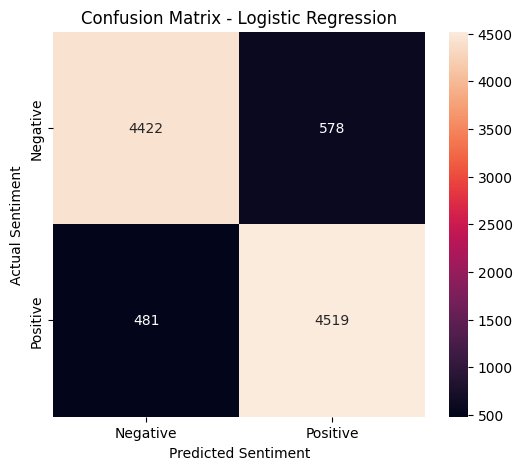

In [132]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [133]:
# Create the comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_nb,
        accuracy_svm
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.8941,89.41
1,Naive Bayes,0.8631,86.31
2,SVM,0.8930,89.30


In [134]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy (%)"], "%")

Best Model: Logistic Regression
Best Accuracy: 89.41 %


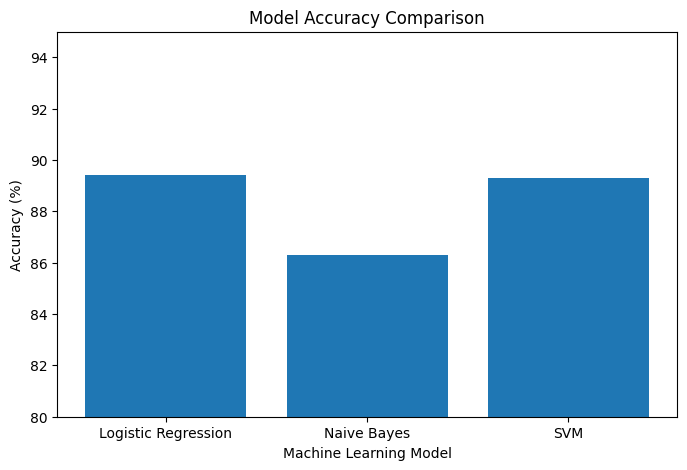

In [135]:
#  Make a comparison graph

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(80, 95)

plt.show()

In [136]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    review_tfidf = tfidf.transform([cleaned_review])
    
    prediction = model_lr.predict(review_tfidf)[0]
    
    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [137]:
review = "This movie was absolutely amazing and I loved every moment of it!"

predict_sentiment(review)

'Positive'

In [138]:
review = "This movie was terrible, boring and a complete waste of time."

predict_sentiment(review)

'Negative'

In [139]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\navya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [140]:
import joblib

In [141]:
joblib.dump(model_lr, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

In [142]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [143]:
import os

print(os.listdir())

['IMDb_Sentiment_Analysis.ipynb', 'logistic_regression_model.pkl', 'tfidf_vectorizer.pkl']


In [144]:
import os

os.makedirs("../models", exist_ok=True)
print("models folder created")

models folder created


In [145]:
import shutil

shutil.move(
    "logistic_regression_model.pkl",
    "../models/logistic_regression_model.pkl"
)

shutil.move(
    "tfidf_vectorizer.pkl",
    "../models/tfidf_vectorizer.pkl"
)

print("Model files moved successfully")

Model files moved successfully
